# 안면마비 기반 뇌졸중 조기 인지 — 전이학습 CNN + Grad-CAM

> **이 노트북의 목적**
> 얼굴 이미지에서 **안면마비(정상 vs 마비)** 를 자동 판별하는 이미지 분류기를,
> 사전학습 CNN(ResNet50)을 **전이학습(Transfer Learning)** 해서 직접 만들고 평가한다.
> 마지막엔 **Grad-CAM** 으로 "모델이 얼굴의 어디를 보고 판단했는지" 를 시각화해,
> 의학적 소견(입꼬리·눈가 비대칭)과 모델의 근거가 맞는지 점검한다.

---

### 왜 이 프로젝트인가 (의학적 배경)

- 뇌졸중은 **골든타임(약 4.5시간)** 안에 치료해야 후유증이 적은데, 절반 이상의 환자가 이 시간을 놓친다.
- 국제 표준 인지법인 **FAST** 의 첫 글자 **F(Face)** 가 곧 **안면마비** — "미소 지을 때 한쪽 입꼬리가 처지는지" 를 본다.
- 안면마비는 FAST 징후 중 **카메라만으로 비전문가도 관찰 가능한 거의 유일한 신호**다.
- 따라서 "얼굴 사진 → 마비 의심 여부 자동 판별" 은 **일반인이 '병원 가야 하나?' 를 빠르게 판단하도록 돕는 스크리닝 보조** 로서 의학적 의미가 있다.

> ⚠️ **이 모델은 진단 도구가 아니다.** 의료적 판단을 대체하지 않으며, 어디까지나 "빨리 알아채기" 를 돕는 비임상 보조 프로토타입이다.

---

### 접근 방법 (왜 전이학습 CNN인가)

이전 버전은 얼굴 랜드마크로 좌우 비대칭 지표를 **사람이 임계값으로** 판단했다.
이번엔 **모델이 데이터에서 직접 특징을 학습**하도록 바꾼다.
- 의료 이미지는 **데이터가 적다** → 밑바닥부터 CNN을 학습시키면 과적합.
- 그래서 **ImageNet으로 미리 학습된 ResNet50** 을 가져와, 마지막 분류층만 우리 문제(정상/마비)에 맞게 학습한다.
- 이 분야 논문들도 ResNet50 / VGG16 / InceptionV3 전이학습을 표준으로 쓴다.


## 1. 환경 설정

Google Colab 기준. 상단 메뉴 **런타임 → 런타임 유형 변경 → 하드웨어 가속기: GPU (T4)** 로 설정하면 학습이 훨씬 빠르다.

In [1]:
# 필요한 라이브러리 import
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 재현성(같은 결과가 나오도록)을 위해 시드 고정
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# GPU가 잡히는지 확인 — []가 나오면 CPU라 느림. 위 안내대로 GPU 런타임으로 바꿀 것.
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 데이터셋 준비 (Kaggle)

추천 데이터셋: **`kaitavmehta/facial-droop-and-facial-paralysis-image`**
(안면처짐/마비 이미지. 전이학습 연구들이 실제로 사용한 표준 데이터)

### 방법 A — Kaggle API로 자동 다운로드 (추천)
1. Kaggle → 우측 상단 프로필 → **Settings → API → Create New Token** → `kaggle.json` 다운로드
2. 아래 셀 실행 후 그 `kaggle.json` 을 업로드

### 방법 B — 직접 업로드
Kaggle 데이터셋 페이지에서 zip을 받아 Colab 왼쪽 파일창에 올린 뒤,
아래 `DATA_DIR` 만 압축 푼 경로로 바꿔도 된다.

In [8]:
# ===== Kaggle 토큰 (Colab Secrets 방식, 비밀이름 자동 탐색) =====
import os
from google.colab import userdata

# 🔑에 저장한 비밀 이름이 뭐든(KAGGLE_TOKEN 이든 facial 이든) 알아서 찾는다
KAGGLE_TOKEN = None
for name in ["KAGGLE_TOKEN", "facial", "kaggle", "KAGGLE"]:
    try:
        KAGGLE_TOKEN = userdata.get(name).strip()
        print(f"비밀 '{name}' 사용")
        break
    except Exception:
        continue

assert KAGGLE_TOKEN, "🔑에 토큰이 없습니다. 왼쪽 열쇠 아이콘에서 비밀을 추가하고 '노트북 액세스'를 켜세요."
assert KAGGLE_TOKEN.isascii(), "토큰에 한글/공백이 섞였습니다. Kaggle에서 토큰을 다시 복사하세요."
assert KAGGLE_TOKEN.startswith("KGAT"), "토큰이 KGAT 로 시작하지 않습니다. 다시 확인하세요."

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

!pip install -q -U kaggle
!kaggle datasets download -d kaitavmehta/facial-droop-and-facial-paralysis-image
!unzip -o -q facial-droop-and-facial-paralysis-image.zip -d ./facial_palsy_data
print("다운로드 완료")

비밀 'KAGGLE_TOKEN' 사용
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 12.4 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/kaitavmehta/facial-droop-and-facial-paralysis-image
License(s): unknown
100% 19.0M/19.0M [00:00<00:00, 65.6MB/s]

다운로드 완료


In [9]:
# ===== 데이터 폴더 구조 확인 =====
# Kaggle 데이터셋마다 폴더 구조가 다르다. 먼저 구조를 눈으로 확인하고
# 클래스(정상/마비)별 폴더가 어디 있는지 파악한 뒤 DATA_DIR을 정한다.

BASE = "./facial_palsy_data"   # 방법 B로 직접 올렸으면 여기를 압축 푼 경로로 변경

for root, dirs, fnames in os.walk(BASE):
    # 너무 길지 않게: 폴더 경로 + 그 안의 이미지 개수만 출력
    n_img = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
    depth = root.replace(BASE, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root) or BASE}/  (이미지 {n_img}장, 하위폴더 {len(dirs)}개)")

facial_palsy_data/  (이미지 0장, 하위폴더 1개)
  Strokefaces/  (이미지 0장, 하위폴더 2개)
    droopy/  (이미지 1024장, 하위폴더 0개)
    normal/  (이미지 0장, 하위폴더 0개)


**위 출력을 보고 `DATA_DIR` 을 정한다.**
`image_dataset_from_directory` 는 **"클래스 이름 = 하위 폴더 이름"** 으로 자동 라벨링한다.
즉 아래처럼 클래스별 폴더가 한 단계 아래에 있는 폴더를 `DATA_DIR` 로 지정하면 된다.

```
DATA_DIR/
 ├─ palsy/    (또는 droop, abnormal ...)
 │   ├─ img1.jpg ...
 └─ normal/   (또는 healthy ...)
     ├─ img1.jpg ...
```
폴더 이름이 다르면 그대로 둬도 된다 — 코드가 폴더명을 클래스로 자동 인식한다.

## 2.5 정상 데이터 추가 + 편향 점검 + 얼굴 정렬 (중요)

받은 데이터는 **마비(`droopy`) 한 클래스뿐**이다. 이진분류를 하려면 **정상(normal)** 클래스가 필요하다.
그런데 정상 얼굴을 다른 데이터셋에서 가져오면 **출처가 달라지는 함정**이 생긴다:

| | droopy(마비) | normal(정상) |
|---|---|---|
| 출처 | 환자 영상 프레임 | 웹 스크래핑 |
| 포즈/표정 | 말하는 중, 비정면 많음 | 제각각 |
| 화질/배경 | 캡처라 흐릿 | 다양 |

→ 이대로 학습하면 모델이 **"입꼬리 비대칭"이 아니라 "화질·배경·포즈"** 로 마비를 맞힐 수 있다.
정확도가 높아도 **가짜 성능**이다. 그래서 아래 순서로 통제한다:

1. 정상 데이터 다운로드 후 **마비와 1:1 개수 균형**
2. 두 클래스를 **눈으로 비교**(peek) — 차이를 직접 확인
3. **얼굴만 크롭 + 정면 얼굴만 통과**(OpenCV) → 배경 제거 + 포즈 통제
4. 나중에 **Grad-CAM**으로 모델이 진짜 얼굴 부위를 보는지 검증

> 이 "편향을 인지하고 통제했다"는 과정 자체가 이 프로젝트의 핵심 실력 포인트다.

In [10]:
# ===== (1) 정상(normal) 얼굴 데이터 다운로드 =====
import os, random, shutil

# 사람 얼굴 7.2k장 (인종/연령/성별 골고루)
!kaggle datasets download -d ashwingupta3012/human-faces
!unzip -o -q human-faces.zip -d ./normal_faces_raw

# 받은 이미지가 실제로 들어있는 폴더를 자동으로 찾는다
NORMAL_SRC = None
for root, dirs, files in os.walk("./normal_faces_raw"):
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(imgs) > 50:
        NORMAL_SRC = root
        print(f"정상 얼굴 폴더: {root}  (이미지 {len(imgs)}장)")
        break

# 마비 개수 + 여유분(버퍼)만큼만 정상에서 복사 (정면필터에서 일부 탈락하므로 버퍼를 둔다)
DROOPY_DIR = "./facial_palsy_data/Strokefaces/droopy"
NORMAL_DIR = "./facial_palsy_data/Strokefaces/normal"
os.makedirs(NORMAL_DIR, exist_ok=True)

n_droopy = len([f for f in os.listdir(DROOPY_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
BUFFER = int(n_droopy * 1.5)   # 정면필터 탈락 대비 1.5배 확보

all_normal = [f for f in os.listdir(NORMAL_SRC) if f.lower().endswith(('.jpg','.jpeg','.png'))]
random.seed(42)
picked = random.sample(all_normal, min(BUFFER, len(all_normal)))
for f in picked:
    shutil.copy(os.path.join(NORMAL_SRC, f), os.path.join(NORMAL_DIR, f))

print(f"마비(droopy): {n_droopy}장 / 정상(normal): {len(os.listdir(NORMAL_DIR))}장 복사 완료")

Dataset URL: https://www.kaggle.com/datasets/ashwingupta3012/human-faces
License(s): CC0-1.0
100% 1.82G/1.82G [00:20<00:00, 94.3MB/s]

정상 얼굴 폴더: ./normal_faces_raw/Humans  (이미지 7219장)
마비(droopy): 1024장 / 정상(normal): 1536장 복사 완료


/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


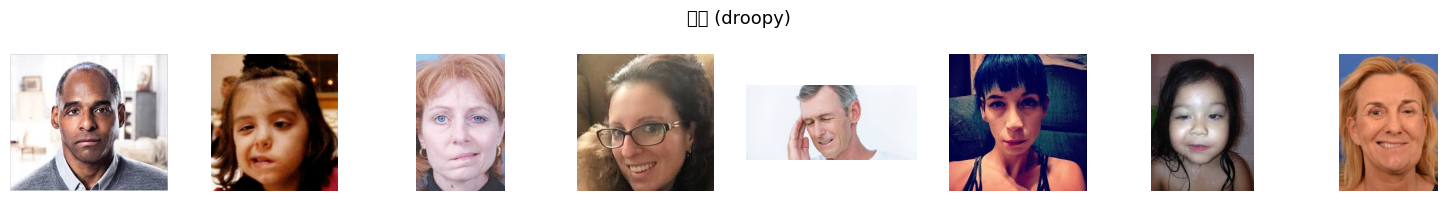

/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


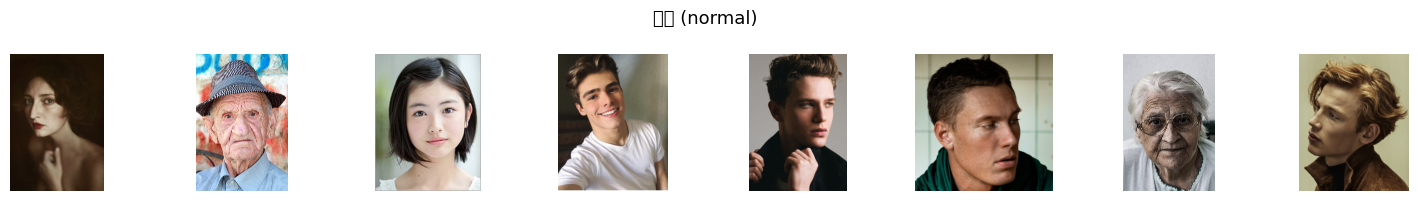

In [11]:
# ===== (2) 두 클래스를 눈으로 비교 =====
import matplotlib.pyplot as plt
import cv2, os

def peek(folder, title, n=8):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    files = files[:n]
    plt.figure(figsize=(15, 2))
    for i, f in enumerate(files):
        img = cv2.imread(os.path.join(folder, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1); plt.imshow(img); plt.axis('off')
    plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

peek("./facial_palsy_data/Strokefaces/droopy", "마비 (droopy)")
peek("./facial_palsy_data/Strokefaces/normal", "정상 (normal)")
# ↑ 두 줄을 비교: 화질/배경/포즈가 확 다르면 그게 모델이 악용할 편향이다.

### (3) 얼굴 크롭 + 정면 필터

OpenCV 정면 얼굴 검출기로 **두 가지를 동시에** 처리한다:
- **얼굴만 잘라냄** → 배경·머리·옷 같은 잡음 제거 (출처 차이를 줄임)
- **정면 얼굴이 검출 안 되는 이미지는 탈락** → 비정면·저품질 자동 제거 (포즈 통제)

결과는 `./dataset_clean/droopy`, `./dataset_clean/normal` 에 저장된다.

In [12]:
# ===== (3) 얼굴 크롭 + 정면 얼굴만 통과 =====
import cv2, os, random

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

SRC_ROOT = "./facial_palsy_data/Strokefaces"
DST_ROOT = "./dataset_clean"
CLASSES = ["droopy", "normal"]
MARGIN = 0.25   # 얼굴 박스 주변 여유 비율
OUT = 224

def crop_class(cls):
    src = os.path.join(SRC_ROOT, cls)
    dst = os.path.join(DST_ROOT, cls)
    os.makedirs(dst, exist_ok=True)
    files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    kept = 0
    for f in files:
        img = cv2.imread(os.path.join(src, f))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1,
                                              minNeighbors=5, minSize=(60, 60))
        if len(faces) == 0:
            continue   # 정면 얼굴 검출 실패 -> 탈락
        x, y, w, h = max(faces, key=lambda b: b[2]*b[3])   # 가장 큰 얼굴
        mx, my = int(w*MARGIN), int(h*MARGIN)
        x0, y0 = max(0, x-mx), max(0, y-my)
        x1, y1 = min(img.shape[1], x+w+mx), min(img.shape[0], y+h+my)
        crop = cv2.resize(img[y0:y1, x0:x1], (OUT, OUT))
        cv2.imwrite(os.path.join(dst, f), crop)
        kept += 1
    return len(files), kept

for c in CLASSES:
    total, kept = crop_class(c)
    print(f"{c}: 원본 {total}장 -> 정면 얼굴 크롭 {kept}장 (탈락 {total-kept})")

# 두 클래스 수를 적은 쪽에 맞춰 균형 맞추기 (1:1)
random.seed(42)
counts = {c: len(os.listdir(os.path.join(DST_ROOT, c))) for c in CLASSES}
m = min(counts.values())
for c in CLASSES:
    fs = os.listdir(os.path.join(DST_ROOT, c))
    for f in random.sample(fs, len(fs)-m):
        os.remove(os.path.join(DST_ROOT, c, f))
print("\n균형 후 최종:", {c: len(os.listdir(os.path.join(DST_ROOT, c))) for c in CLASSES})

droopy: 원본 1024장 -> 정면 얼굴 크롭 904장 (탈락 120)
normal: 원본 1536장 -> 정면 얼굴 크롭 1350장 (탈락 186)

균형 후 최종: {'droopy': 904, 'normal': 904}


/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 47213 (\N{HANGUL SYLLABLE ROB}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/

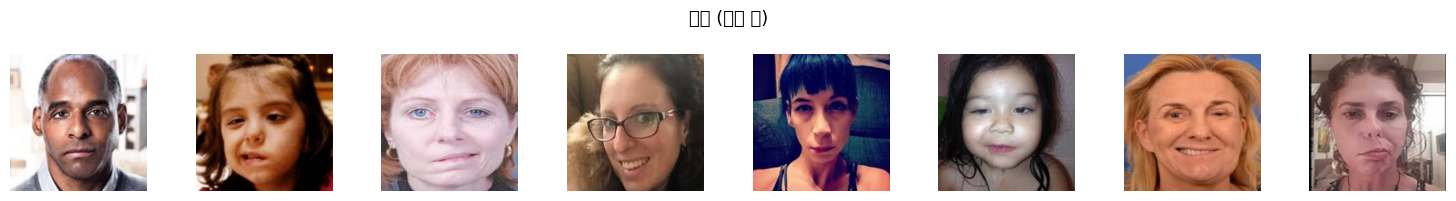

/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()
/tmp/ipykernel_2845/2257417890.py:13: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()


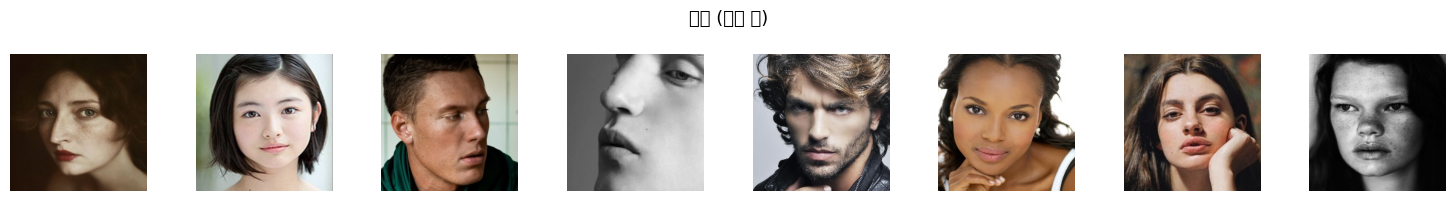

In [13]:
# ===== 크롭 결과 확인 (얼굴 정렬이 잘 됐는지) =====
peek("./dataset_clean/droopy", "마비 (크롭 후)")
peek("./dataset_clean/normal", "정상 (크롭 후)")
# 둘 다 '얼굴 위주'로 비슷하게 잘렸으면 성공. 배경·포즈 차이가 크게 줄었을 것.

In [14]:
# 얼굴 크롭/정면필터까지 끝난 정리된 데이터 폴더를 가리킨다.
# (이 안에 droopy/, normal/ 두 클래스 폴더가 있음)
DATA_DIR = "./dataset_clean"

IMG_SIZE = (224, 224)   # ResNet50 입력 크기
BATCH_SIZE = 32

## 3. 데이터 로딩 + train/validation 분할

- `image_dataset_from_directory` 로 폴더에서 바로 이미지를 읽는다.
- `validation_split=0.2` → 데이터의 80%는 학습, 20%는 검증용으로 자동 분리.
- **같은 seed** 를 줘야 train/val이 겹치지 않게 똑같은 기준으로 나뉜다.

In [15]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",   # 이진분류(0/1)
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

# 클래스 이름 확인 — [0번 클래스, 1번 클래스] 순서. 어느 폴더가 0이고 1인지 꼭 기억!
class_names = train_ds.class_names
print("클래스:", class_names, " → 0 =", class_names[0], ", 1 =", class_names[1])

Found 1808 files belonging to 2 classes.
Using 1447 files for training.
Found 1808 files belonging to 2 classes.
Using 361 files for validation.
클래스: ['droopy', 'normal']  → 0 = droopy , 1 = normal


In [16]:
# 성능 최적화: 데이터를 메모리에 캐시하고 미리 불러오기(prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

## 4. 데이터 살펴보기 (EDA)

모델을 짜기 전에 **데이터를 눈으로 보는 게 먼저**다.
- 이미지가 제대로 읽혔는지, 라벨이 맞는지
- 클래스 불균형(한쪽이 너무 많은지)은 없는지 — 불균형하면 정확도가 착시를 일으킨다

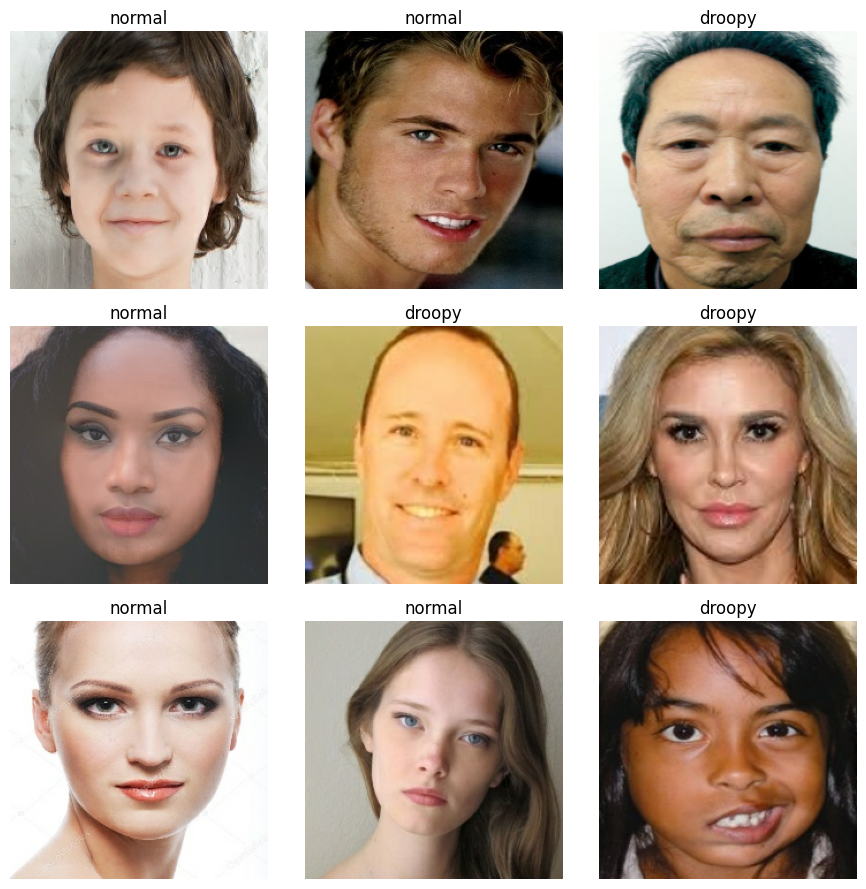

In [17]:
# 샘플 이미지 9장 + 라벨 출력
plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        idx = int(labels[i].numpy()[0])
        plt.title(class_names[idx])
        plt.axis("off")
plt.tight_layout(); plt.show()

In [18]:
# 클래스 분포 확인 (불균형 체크)
from collections import Counter
cnt = Counter()
for _, labels in train_ds.unbatch():
    cnt[int(labels.numpy()[0])] += 1
print("학습 데이터 클래스 분포:")
for k in sorted(cnt):
    print(f"  {class_names[k]} ({k}): {cnt[k]}장")
# 한쪽이 2배 이상 많으면 → 아래 모델 학습에서 class_weight를 고려할 것(주석 참고)

학습 데이터 클래스 분포:
  droopy (0): 735장
  normal (1): 712장


## 5. 데이터 증강 + 전처리

데이터가 적으므로 **증강(augmentation)** 으로 다양성을 늘린다.

> 💡 **이 도메인에서 중요한 판단 — 좌우 반전(horizontal flip)을 쓸까?**
> 안면마비는 "좌우 비대칭" 이 핵심이다. 좌우를 뒤집어도 *비대칭은 그대로 비대칭* 이라
> "정상 vs 마비" 이진분류에서는 반전을 써도 무방하다(마비된 쪽만 좌↔우 바뀔 뿐).
> 다만 "왼쪽 마비 vs 오른쪽 마비" 처럼 **방향까지 구분하는 문제라면 반전은 쓰면 안 된다.**
> 여기선 정상/마비만 보므로 가벼운 반전·회전·밝기 변화만 적용한다.

In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),    # 위 주석 참고 (정상/마비 이진분류라 허용)
    layers.RandomRotation(0.05),        # ±약 18도 이내 살짝 회전
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

# ResNet50 전용 전처리 함수 (0~255 → ResNet이 기대하는 형태로 변환)
preprocess_input = keras.applications.resnet50.preprocess_input

## 6. 모델 구축 — 전이학습 (ResNet50)

구조:
1. **ResNet50 (ImageNet 사전학습)** 을 가져온다 — `include_top=False` 로 분류층은 떼고 특징 추출기만 사용.
2. 이 특징 추출기는 **얼린다(freeze)** — ImageNet에서 배운 일반적인 시각 특징(엣지·질감 등)을 유지.
3. 그 위에 우리 문제용 **새 분류 헤드** (GlobalAveragePooling → Dropout → Dense 1개, sigmoid)를 얹는다.

이렇게 하면 적은 데이터로도 안정적으로 학습된다.

In [20]:
# 1) 사전학습된 ResNet50 백본 (분류층 제거)
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False   # 2) 백본 동결 (1단계 학습에서는 헤드만 학습)

# 3) 전체 모델 조립
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)          # 증강(학습 때만 작동)
x = preprocess_input(x)                # ResNet 전용 전처리
x = base_model(x, training=False)      # 동결된 백본으로 특징 추출
x = layers.GlobalAveragePooling2D()(x) # 특징맵 → 벡터
x = layers.Dropout(0.3)(x)             # 과적합 방지
outputs = layers.Dense(1, activation="sigmoid")(x)  # 이진분류 출력(0~1 확률)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")],
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. 1단계 학습 — 분류 헤드만 학습

백본은 얼린 채, 새로 붙인 분류 헤드만 먼저 학습시킨다.

> 💡 **재현율(Recall)을 눈여겨봐야 한다.** 스크리닝에서는 "마비를 놓치지 않는 것" 이 가장 중요하다.
> 정확도가 높아도 재현율이 낮으면 실제 환자를 놓친다는 뜻 → 도구로서 위험.
> (지난 우울증 연구에서 재현율이 낮아 환자를 대부분 놓쳤던 것과 같은 교훈)

In [21]:
# 클래스 불균형이 심하면 아래 두 줄 주석을 풀어 class_weight를 넘긴다.
# from sklearn.utils.class_weight import compute_class_weight
# (직접 계산해 dict로 model.fit(..., class_weight=...)에 전달)

EPOCHS = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                      restore_best_weights=True),
    ],
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 253ms/step - accuracy: 0.7740 - loss: 0.4798 - precision: 0.7670 - recall: 0.7767 - val_accuracy: 0.9197 - val_loss: 0.2287 - val_precision: 0.8937 - val_recall: 0.9635
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.8991 - loss: 0.2625 - precision: 0.8909 - recall: 0.9059 - val_accuracy: 0.9474 - val_loss: 0.1763 - val_precision: 0.9220 - val_recall: 0.9844
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.9261 - loss: 0.2054 - precision: 0.9207 - recall: 0.9298 - val_accuracy: 0.9418 - val_loss: 0.1694 - val_precision: 0.9130 - val_recall: 0.9844
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9330 - loss: 0.1833 - precision: 0.9399 - recall: 0.9228 - val_accuracy: 0.9612 - val_loss: 0.1471 - val_precision: 0.9450 - val_recall: 0.9844
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9461 - loss: 0.1556 - precision: 0.9465 - recall: 0.9438 - val_accuracy: 0.9446 - val_loss: 0

In [29]:
# 시각화 라이브러리 임포트
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료")

한글 폰트 설정 완료


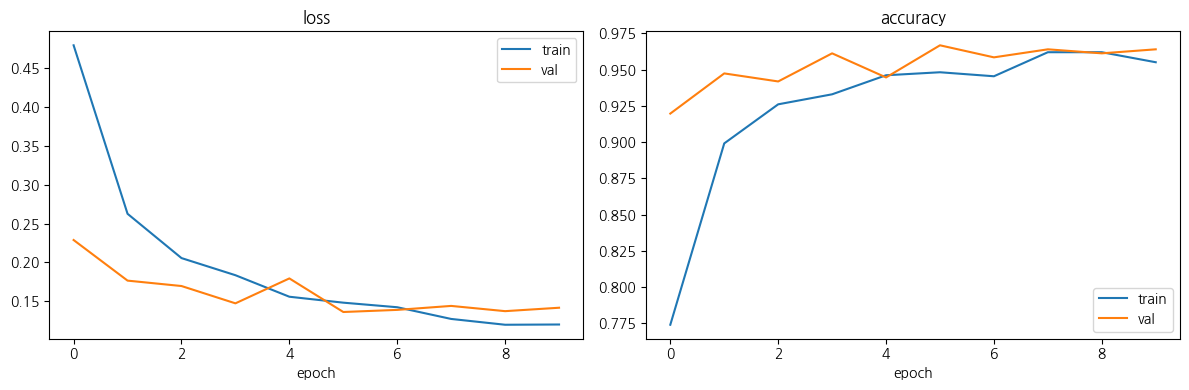

In [30]:
# 학습 곡선 — train vs val을 비교해 과적합 여부를 본다
def plot_history(h):
    metrics = ["loss", "accuracy"]
    plt.figure(figsize=(12, 4))
    for i, m in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.plot(h.history[m], label="train")
        plt.plot(h.history["val_"+m], label="val")
        plt.title(m); plt.xlabel("epoch"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history)
# val 곡선이 train과 크게 벌어지면 과적합 신호 (데이터 적을 때 흔함)

## 8. (선택) 2단계 — 미세조정 (Fine-tuning)

성능을 더 끌어올리고 싶으면, 동결했던 백본의 **상위 일부 층만 풀어서** 아주 작은 학습률로 재학습한다.
데이터가 적으면 생략해도 된다(과적합 위험). 여유 있으면 실행.

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 262ms/step - accuracy: 0.9883 - loss: 0.0510 - precision: 0.9874 - recall: 0.9888 - val_accuracy: 0.9640 - val_loss: 0.1431 - val_precision: 0.9453 - val_recall: 0.9896
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.9883 - loss: 0.0468 - precision: 0.9860 - recall: 0.9902 - val_accuracy: 0.9640 - val_loss: 0.1452 - val_precision: 0.9453 - val_recall: 0.9896
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.9917 - loss: 0.0370 - precision: 0.9944 - recall: 0.9888 - val_accuracy: 0.9640 - val_loss: 0.1550 - val_precision: 0.9453 - val_recall: 0.9896
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9945 - loss: 0.0305 - precision: 0.9944 - recall: 0.9944 - val_accuracy: 0.9612 - val_loss: 0.1521 - val_precision: 0.9406 - val_recall: 0.9896


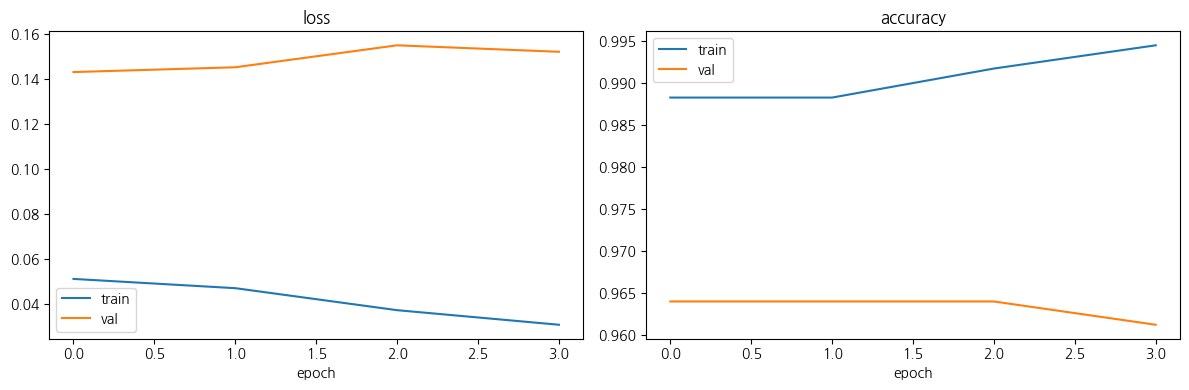

In [31]:
# 백본의 뒷부분 층만 학습 가능하게 풀기
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 20   # 마지막 20개 층만 학습
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# 미세조정은 학습률을 훨씬 작게 (기존 가중치를 망가뜨리지 않도록)
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")],
)

history_ft = model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",
                                             patience=3, restore_best_weights=True)],
)
plot_history(history_ft)

## 9. 평가 — 혼동행렬 + 분류 리포트

정확도 하나만 보면 안 된다. **혼동행렬 / 정밀도 / 재현율 / F1** 을 함께 본다.
특히 "마비를 정상으로 잘못 본(놓친)" 칸이 몇 개인지가 스크리닝에선 가장 치명적이다.

              precision    recall  f1-score   support

      droopy     0.9875    0.9349    0.9605       169
      normal     0.9453    0.9896    0.9669       192

    accuracy                         0.9640       361
   macro avg     0.9664    0.9622    0.9637       361
weighted avg     0.9650    0.9640    0.9639       361



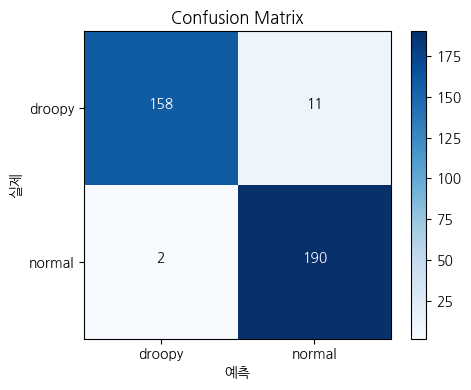

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# 검증셋 전체에 대해 예측 수집
y_true, y_prob = [], []
for images, labels in val_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs)
    y_true.extend(labels.numpy().ravel())
y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)   # 0.5 임계값 (필요시 조정)

# 분류 리포트
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 혼동행렬 시각화
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names); plt.yticks(ticks, class_names)
plt.xlabel("예측"); plt.ylabel("실제")
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center",
             color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

> 💡 **임계값(threshold) 조정 아이디어**
> 마비를 놓치는 게 더 위험하다면, 임계값을 0.5보다 낮춰(예: 0.35) **재현율을 올릴 수 있다.**
> 대신 정상인을 마비로 오인하는 경우(오탐)가 늘어난다 — 이 트레이드오프를 설명할 수 있으면 면접에서 강점.

## 10. Grad-CAM — 모델은 얼굴의 어디를 보는가?

**이 프로젝트의 핵심 차별점.**
모델이 "마비" 라고 판단할 때, 실제로 **입꼬리·눈가 같은 비대칭 부위** 를 보고 있는지를 히트맵으로 확인한다.
- 모델이 얼굴의 의학적으로 의미 있는 부위를 본다면 → 신뢰할 만한 근거로 학습됨
- 엉뚱한 배경·머리카락을 본다면 → 데이터 편향 의심 (좋은 회고거리)

In [33]:
# ===== Grad-CAM 정식 구현 =====
# 핵심 아이디어: '최종 예측확률'을 '마지막 conv 특징맵'으로 미분하면,
# 어느 공간 위치가 예측에 크게 기여했는지(=모델이 주목한 곳)를 알 수 있다.
# ResNet50(include_top=False)의 출력이 곧 마지막 conv 특징맵(7x7x2048)이다.

# 학습된 model에서 헤드 층(GAP, Dense)을 꺼낸다 (Dropout은 추론 시 무시)
gap_layer   = [l for l in model.layers if isinstance(l, layers.GlobalAveragePooling2D)][0]
dense_layer = [l for l in model.layers if isinstance(l, layers.Dense)][0]

# base_model 입력 -> 마지막 conv 특징맵을 내보내는 모델
feat_model = keras.models.Model(base_model.input, base_model.output)

def gradcam_heatmap(preprocessed):
    # preprocessed: ResNet 전처리까지 끝난 (1,224,224,3) 배열
    with tf.GradientTape() as tape:
        conv_out = feat_model(preprocessed)     # (1,7,7,2048) 마지막 conv 특징맵
        tape.watch(conv_out)                    # 중간 텐서라 명시적으로 watch
        x = gap_layer(conv_out)                 # 학습된 헤드를 그대로 적용
        pred = dense_layer(x)                   # (1,1) 마비 확률
        target = pred[:, 0]
    grads = tape.gradient(target, conv_out)             # 예측에 대한 특징맵 기여도
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))      # 채널별 중요도
    hm = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])
    hm = tf.maximum(hm, 0) / (tf.reduce_max(hm) + 1e-8) # ReLU + 0~1 정규화
    return hm.numpy(), float(pred.numpy().ravel()[0])

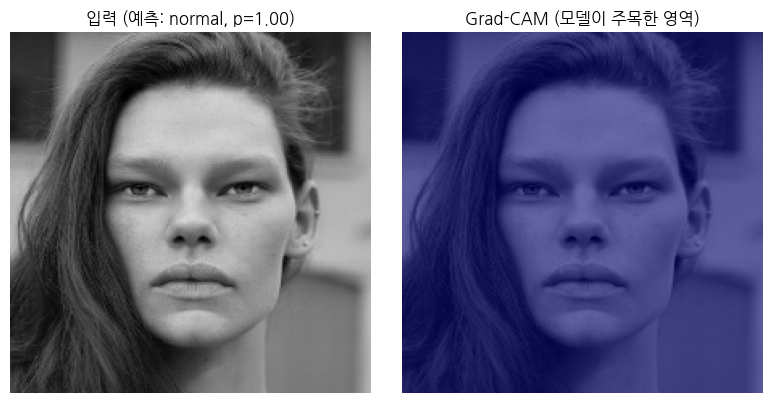

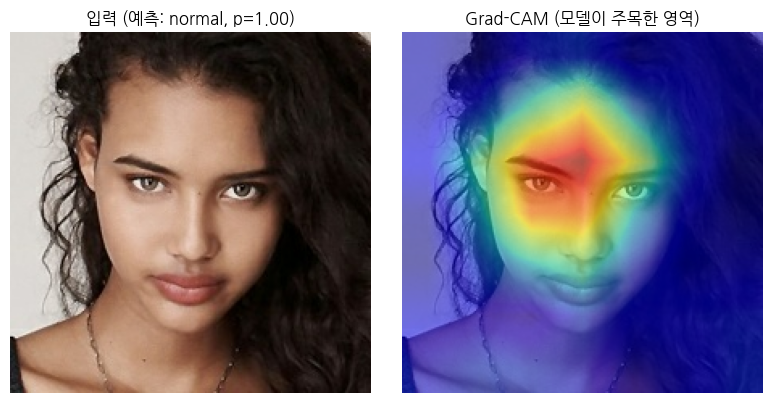

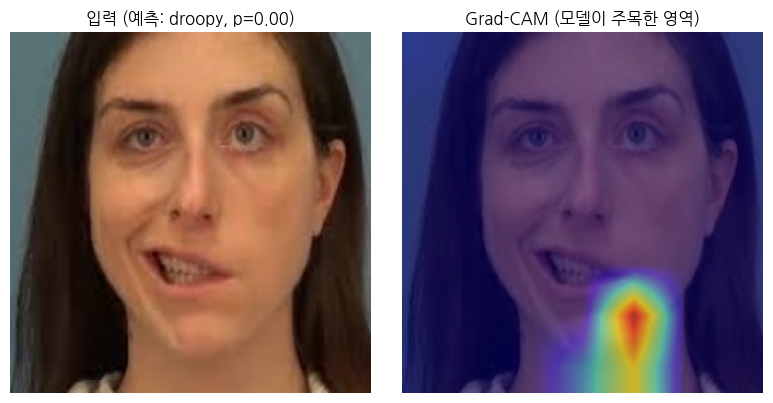

In [34]:
import matplotlib.cm as cm_mpl

def show_gradcam(image_uint8):
    # image_uint8: (224,224,3) uint8 한 장
    raw = np.expand_dims(image_uint8.astype("float32"), 0)

    # 1) 전체 모델로 예측 (model 내부에 전처리 포함이라 raw 입력)
    prob = float(model.predict(raw, verbose=0).ravel()[0])
    pred_label = class_names[int(prob >= 0.5)]

    # 2) Grad-CAM 히트맵 (feat_model은 base_model 입력이라 전처리해서 넣음)
    pre = preprocess_input(raw.copy())
    hm, _ = gradcam_heatmap(pre)

    # 3) 7x7 히트맵을 원본 크기로 키워 오버레이
    hm_resized = tf.image.resize(hm[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    heat = cm_mpl.jet(hm_resized)[..., :3]
    overlay = (0.5 * image_uint8/255.0 + 0.5 * heat)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(image_uint8); ax[0].set_title(f"입력 (예측: {pred_label}, p={prob:.2f})"); ax[0].axis("off")
    ax[1].imshow(overlay); ax[1].set_title("Grad-CAM (모델이 주목한 영역)"); ax[1].axis("off")
    plt.tight_layout(); plt.show()

# 검증셋에서 몇 장 뽑아 확인 -- 입꼬리/눈가에 빨갛게 불이 들어오면 좋은 신호
for images, labels in val_ds.take(1):
    for i in range(3):
        show_gradcam(images[i].numpy().astype("uint8"))

## 11. 한계 및 회고 (Known Issues)

- **이번 실험 결과**: 검증셋 기준 정확도 약 96%, 재현율(마비) 약 0.93 — 마비 169개 중 158개 검출, 정상 192개 중 190개 정확 분류. Grad-CAM 확인 시 모델이 마비 판단에는 입·턱 부위, 정상 판단에는 얼굴 중앙을 근거로 사용함.

- **데이터 출처 편향(가장 중요)**: 마비 데이터(환자 영상 프레임)와 정상 데이터(웹 얼굴)는 출처가 달라, 모델이 얼굴이 아니라 화질·배경·포즈로 구분할 위험이 있었다. 이를 줄이기 위해 **얼굴 크롭 + 정면 얼굴 필터**로 입력 조건을 맞췄고, **Grad-CAM**으로 모델이 실제 얼굴 부위(입꼬리·눈가)를 보는지 검증했다. 그래도 출처 차이를 완전히 제거하진 못한다. 즉 96% 정확도에는 실제 마비 식별 능력과 출처 차이(정상=깨끗한 사진, 마비=거친 영상 프레임)가 함께 섞여 있을 수 있다.
- **데이터 규모/품질**: 공개 데이터라 규모가 작고 라벨 신뢰도가 낮다. 정식 연구라면 임상의가 라벨링한 YFP·MEEI 데이터가 필요하다.
- **임계값 트레이드오프**: 재현율(놓치지 않기)을 높이면 오탐이 는다. 스크리닝 목적상 재현율 우선이 맞지만 비용이 있다.
- **진단이 아님**: 이 모델은 의료 판단을 대체하지 않는다. "병원에 가보라"고 권하는 보조 신호일 뿐이다.

### 다음 단계
1. 임상 라벨 데이터(YFP/MEEI) 확보 후 재학습 → 신뢰도 향상
2. 마비/정상을 **같은 출처·같은 촬영조건**으로 맞춰 편향 제거
3. 재현율 중심 임계값 튜닝 + ROC 곡선 분석
4. 데이터 부족 보완을 위한 **GAN 기반 증강** → 증강 전/후 성능 비교

---
> **요약 서사 (면접용):** "마비 데이터만 있어서 정상 데이터를 합쳤는데, 출처가 달라 모델이 얼굴이 아닌 배경·화질로 구분할 편향을 의심했다. 그래서 얼굴 크롭과 정면 필터로 입력을 통제하고, Grad-CAM으로 모델 근거가 의학적으로 타당한지(입꼬리·눈가) 확인하려 했다."
